# Demo 2: Visualization of atomic environments with cl-MDS
---

This demo shows how to use cl-MDS to visualize different data related to atomistic databases, MD simulations and model training.

Note that while the embedding step can be computed with other dimensionality reduction technique, there are several part in this demo that rely on functionality conveniently available on cl-MDS.

In [1]:
import numpy as np
import cluster_mds as clmds
import matplotlib.pyplot as plt
from weas_widget import WeasWidget

## Quick review of Demo 1
---

```python
import module_name

# initialize the method
method = module_name.class_name( input_parameters )

# run the method
method.get_embedding_name( main_parameters )

# get ouptut
method.output
```

## Analysing a database of Ge-Sb-Te materials
---

In this example, we will analyse a database containing different GST structures.

It includes the training data used for the GST GAP from [J. Phys. Chem. B 2018, 122, 8998−9006](https://pubs.acs.org/doi/10.1021/acs.jpcb.8b06476), as well as:
- dimer and trimer information,
- several melt-quench structures generated through iterative training.

### 1. Understanding the main parameters

In [2]:
# input file
atoms_file = "GST_training_data.xyz"

# directories to store the results
dirname = './results_demo_2/'
dir_medoids = dirname + 'medoids/'

# descriptor information
desc_type = "quippy_soap_turbo"
Z = ["Ge", "Sb", "Te"]
nmax = 4; lmax = 3
rcut_hard = 4.; rcut_soft = rcut_hard - 0.5
at_sr = [0.5, 0.5, 0.5]; at_srs = [0., 0., 0.]
at_st = [0.5, 0.5, 0.5]; at_sts = [0., 0., 0.]
desc_string = {z:'soap_turbo alpha_max={%i %i %i} l_max=%i rcut_soft=%.2f \
                 rcut_hard=%.2f atom_sigma_r={%.2f %.2f %.2f} atom_sigma_t={%.2f %.2f %.2f} \
                 atom_sigma_r_scaling={%.2f %.2f %.2f} atom_sigma_t_scaling={%.2f %.2f %.2f} \
                 radial_enhancement=1 compress_mode=trivial \
                 amplitude_scaling={1. 1. 1.} basis="poly3gauss" \
                 scaling_mode="polynomial" species_Z={32 51 52} n_species=3 \
                 central_index=%i central_weight={1. 1. 1.}'
                 % (nmax, nmax, nmax, lmax, rcut_soft, rcut_hard, at_sr[0],
                    at_sr[1], at_sr[2], at_st[0], at_st[1], at_st[2], at_srs[0], at_srs[1],
                    at_srs[2], at_sts[0], at_sts[1], at_sts[2], i+1)
                 for i, z in enumerate(Z)}

#-------- CHANGE THINGS BELOW -----------------------------------------
# embedding info
do_species = ['Ge']

# clustering
hierarchy = [15,1]
# kmedoids calculations (n. iterations)
iter_med=100
# embedding of clusters (n. iterations, custom weights)
n_init_mds_cluster=100
weight_mds_cluster=8
# anchor points embedding (n. iterations, custom weights)
n_init_mds_anchor=1000
weight_mds_anchor=2
eta=0

### 2. cl-MDS calculations

In [3]:
# Initialize clMDS class passing our own descriptor string
method = clmds.clMDS(atoms=atoms_file, descriptor=desc_type,
                     descriptor_string=desc_string, do_species=do_species,
                     sparsify="random", n_sparse=1000, 
                     verbose=False)

In [4]:
%%time
# Compute 2-dim. representation of the sparse set
method.cluster_MDS(hierarchy,
                 # kmedoids calculations (n. iterations, initialization)
                 iter_med=iter_med, 
                 init_medoids="isolated", n_iso_med=2,
                 # embedding of clusters (n. iterations, n. CPUS, custom weights)
                 n_init_mds_cluster=100, 
                 n_jobs_cluster=4, 
                 weight_cluster_mds=8,
                 # anchor points selection
                 param_anchor=[80,90,90], 
                 # anchor points embedding (n. iterations, n. CPUS, custom weights)
                 n_init_mds_anchor=1000, 
                 n_jobs_anchor=4, 
                 weight_anchor_mds=2, eta=0)

CPU times: user 8.35 s, sys: 483 ms, total: 8.84 s
Wall time: 1min 14s


What is happening under the hood?

In [5]:
# show clMDS class attributes

# from initialization
print("N. structures in training set: %i" % len(method.atoms))
print("Total n. of environments: %i" % method.all_env)
print("Total n. of Ge environments: %i" % method.n_env)
print(" ")
print("N. of sparse points: %i" % method.n_sparse)
Z_sparse = np.array(method.species_list)[method.sparse_list]
print("Chemical species included in the sparse set: ", set(Z_sparse))
print(" ")

# from calculations to prepare the input data (method.build_descriptor, method.build_dist_matrix)
print("SOAP descriptors: ", np.shape(method.descriptor))
print("Distance matrix: ", np.shape(method.dist_matrix))
print("Computed with zeta = %i" % method.zeta)
print(" ")

# from running clMDS
Y = method.sparse_coordinates
M = method.sparse_medoids
C = method.sparse_cluster_indices

print("Clustering information:")
print("i_cl | i_med | N_cl")
print("-------------------")
for i in range(0, hierarchy[0]):
    n = len(np.where( C == i )[0])
    print(" %2i    %4i    %3i" % (i, M[i], n))

N. structures in training set: 4652
Total n. of environments: 93256
Total n. of Ge environments: 26078
 
N. of sparse points: 1000
Chemical species included in the sparse set:  {'Ge'}
 
SOAP descriptors:  (1000, 132)
Distance matrix:  (1000, 1000)
Computed with zeta = 6
 
Clustering information:
i_cl | i_med | N_cl
-------------------
  0      11      1
  1      18      1
  2     198    205
  3      59     31
  4     974    269
  5     509    158
  6     585     51
  7      12      1
  8      37      6
  9     402     61
 10      17      1
 11      21      1
 12      35      1
 13     362    207
 14      15      6


### 3. Visualization

In [6]:
# Save to file
method.save_to_file(dir=dirname)

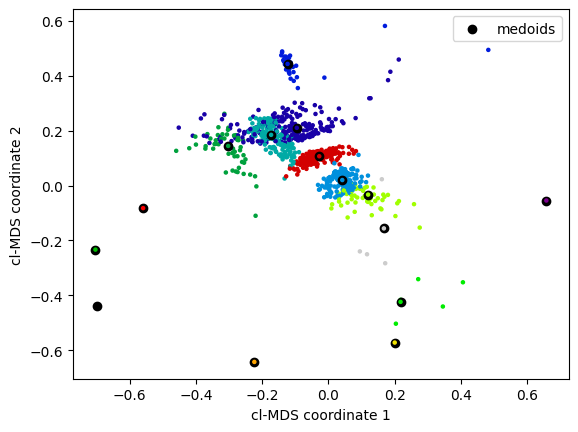

In [7]:
# show plot
# Function to add labels inside a box
def add_labels(x, y, ax):
    for i in range(len(x)):
        ax.text(i, y[i], y[i], ha='center', 
                 bbox=dict(facecolor='magenta', alpha=0.8))


fig, ax = plt.subplots()

ax.scatter(Y[:, 0], Y[:, 1], s=5, c=C, cmap='nipy_spectral')
ax.scatter(Y[M, 0], Y[M, 1], color='black', label='medoids')
ax.scatter(Y[M, 0], Y[M, 1], s=5, c=C[M], cmap='nipy_spectral')
#add_labels(Y[M, 0], Y[M, 1], ax)
ax.set_xlabel(r'cl-MDS coordinate 1')
ax.set_ylabel(r'cl-MDS coordinate 2')

plt.legend()
#plt.savefig(dirname + 'clmds_plot_advanced.png', format='png', dpi=300)
plt.show()


### 4. Representative atomic environments

Medoids correspond to the N most representative points of a dataset, each of them with a cluster associated.
This classification is done such as the members of a cluster are closer to their own medoid than to any other medoid.

Remember that in our case, each point corresponds to an atomic environment with their closeness defined by the kernel, i.e., how similar two environments are. We can use medoids as reference environments for the whole dataset, whether it is to visualize them (as below) or to build better sparse sets (see the last section). 

In [8]:
# Visualize the atomic environments corresponding to the medoids
if method.atoms is not None:
    method.medoids_to_xyz(dir=dir_medoids, carve_radius=4., render=False)
    
    from ase.io import read

    atoms = []
    for i in range(0, len(M)):
        atoms += [read(dir_medoids + "/medoid_%i.xyz" % i)]

    #print("Medoid n. %i" % i)
    viewer = WeasWidget()
    viewer.avr.model_style = 1 # ball & stick mode
    viewer.from_ase(atoms)
    viewer.avr.show_bonded_atoms = True # show bonds across periodic boundaries

viewer

WeasWidget(children=(<weas_widget.base_widget.BaseWidget object at 0x7f58be949210>,))

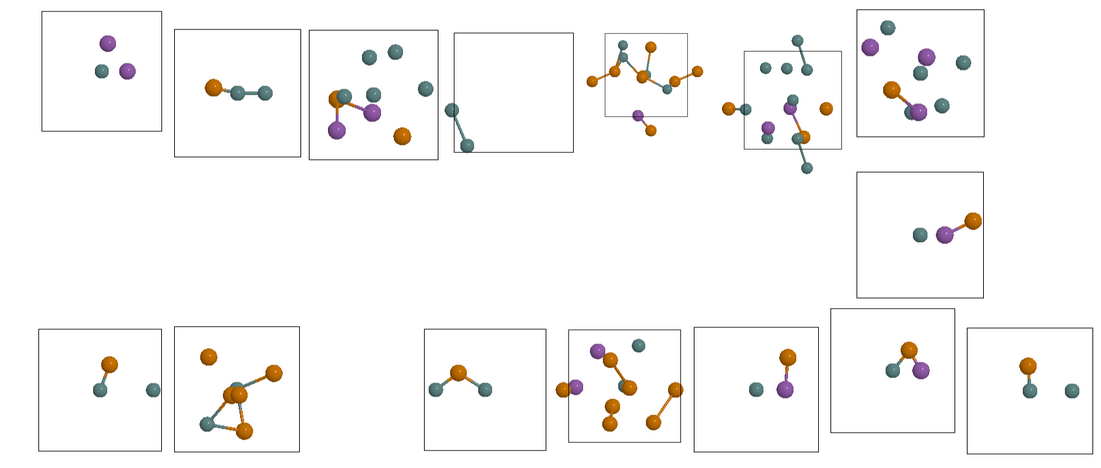

### 4. Adding simulation data on top of the embedding

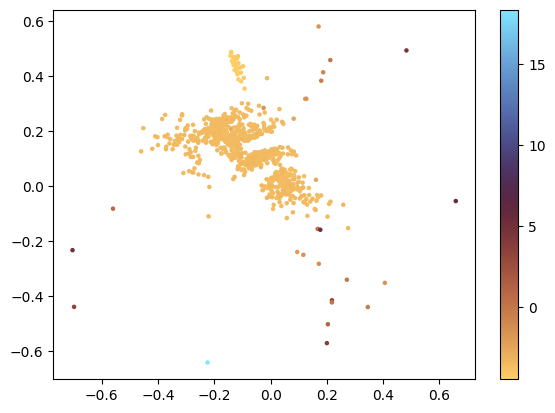

In [9]:
# local energies
from matplotlib import colors

E_local = []
for ats in method.atoms:
    E = ats.get_potential_energy()
    E_per_atom = [E/len(ats)]*len(ats)
    E_local += E_per_atom

E_local = np.array(E_local)

# plot
fig, ax = plt.subplots()

images = ax.scatter(Y[:, 0], Y[:, 1], s=5, c=E_local[method.sparse_list], cmap='managua')

fig.colorbar(images, ax=ax, fraction=.1)
plt.show()

### 5. Estimation of coordinates for additional points

In [10]:
%%time
# Estimate the coordinates for the rest of the database
Y_estim = method.get_estim_coordinates(n_steps=5)
C_estim = Y_estim[:,2].astype(int)

CPU times: user 19.6 s, sys: 285 ms, total: 19.9 s
Wall time: 19.9 s


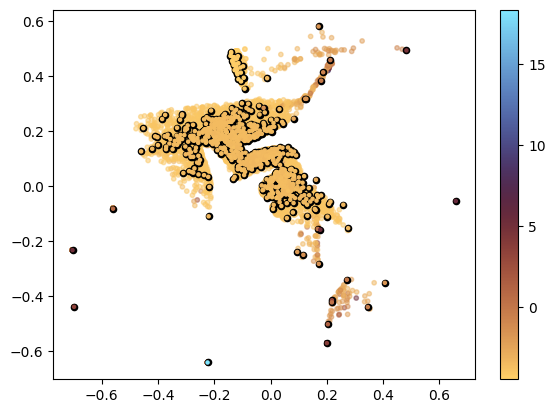

In [11]:
# plot
fig, ax = plt.subplots()

images = ax.scatter(Y_estim[:, 0], Y_estim[:, 1], s=10,
                    c=E_local[method.do_species_list], cmap='managua')
ax.scatter(Y[:, 0], Y[:, 1], s=1, c="black", alpha=0.5, label='sparse set')
#ax.scatter(Y[:, 0], Y[:, 1], s=5, 
#                    c=E_local[method.sparse_list], cmap='managua')


fig.colorbar(images, ax=ax, fraction=.1)
plt.legend()
plt.show()

### 6. Iterative training analysis (evolution of data)

In [12]:
import ipywidgets as widgets
from ipywidgets import interact

# retrieve the indexes of the atomic env coming from different iterations
all_config_types = []
for ats in method.atoms:
    all_config_types += [ats.info['config_type']]*len(ats)

config_types = np.array(all_config_types)[method.do_species_list]
I_init = [i for i in range(0, len(config_types)) if 'iter' not in config_types[i]] 

@interact(n_iter=(1, 8, 1))
def interactive_vis(n_iter=1):
    fig, ax = plt.subplots(figsize=(8, 8))
    images = ax.scatter(Y_estim[:, 0], Y_estim[:, 1], s=10, 
                        c=E_local[method.do_species_list], cmap='managua')

#   iterative training
    I = []
    for n in range(1, n_iter + 1):
        label_iter = 'iter_%i' % n
        I += list(np.where(label_iter == config_types)[0])
            
    ax.scatter(Y_estim[I, 0], Y_estim[I, 1], color='red', 
               label='melt-quench struct.', s=3)
    
    ax.set_title(f"n_iter={n_iter}")
    fig.colorbar(images, ax=ax, fraction=.1)
    plt.legend()
    plt.show()

interactive(children=(IntSlider(value=1, description='n_iter', max=8, min=1), Output()), _dom_classes=('widget…

## Additional features
---

### Custom sparsification and clustering

Custom sparsification is useful as a preprocessing step for cl-MDS, ensuring a better preservation of all the features contained in a database. That said, it is an important strategy in other contexts, such as training a ML model (e.g., with `gap_fit`).

There are several approaches to sparsification, but the implementations below are developed with very big datasets in mind.

In particular, `use_method=medoids` allows the computation of clusterings for those cases where it is not possible to run k-medoids directly, due to the size of the full distance matrix.

In [ ]:
%%time
# Generate a custom list/array of sparse indices
generate_sparse = False
filename_sparse = 'improved_sparse_set.txt'
use_method = "optim"   # "medoids" | "rand_medoids" | "optim"

if generate_sparse:
#   Compute a custom sparse set using sparsify_module
    import sparsify_module as spmod
    
    n_sparse = 1000 # reference size of the sparse set
    P_med = 15  # approx. percentage of medoids in the sparse set
               # lower it (15-20) for databases with more than 30000 atoms
#   (1) only medoids in the sparse set
    if use_method == "medoids":
        custom_sparse = spmod.sparsify_kmedoids( atoms=atoms_file, descriptor=desc_type, 
                                                do_species=do_species, descriptor_string=desc_string,
                                                max_n_sparse=n_sparse, percentage_med=P_med )

#   (2) medoids + random points in the sparse set
    if use_method == "rand_medoids":
        custom_sparse = spmod.sparsify_rand_and_kmedoids( n_sparse, atoms=atoms_file, do_species=do_species,
                                                         descriptor=desc_type, descriptor_string=desc_string, 
                                                         percentage_med=P_med )

#   (3) optimized version of (1), (2) for a given number of clusters 
    if use_method == "optim":
#       it ensures a minimum number of points per cluster in the sparse set,
#       improving cl-MDS performance but much slower
        custom_sparse = spmod.sparsify_cluster_size( n_sparse, hierarchy[0], atoms=atoms_file, 
                                                     descriptor=desc_type, descriptor_string=desc_string, 
                                                     do_species=do_species, percentage_med=P_med, 
                                                     min_cluster_size=5, max_iter=15 )

#   It is recommended to save the sparse set for further uses/testing parameters
    np.savetxt(filename_sparse, custom_sparse, fmt='%i')